In [5]:
import yfinance as yf
import pandas as pd

# 1. Define the tickers, including the S&P 500 at the end
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META',  # Tech
    'JPM', 'BAC', 'GS', 'MS', 'C',            # Finance
    'JNJ', 'UNH', 'PFE', 'MRK', 'ABBV',       # Healthcare
    'XOM', 'CVX', 'COP', 'SLB', 'EOG',        # Energy
    '^GSPC'                                   # S&P 500 Market Index
]

print("Downloading all market data from Yahoo Finance...")

# 2. Download and slice only the 'Close'
df = yf.download(tickers, start="2020-01-01", end="2024-01-01")['Close']

# 3. Rename the S&P 500 column to drop the special characters
df.rename(columns={'^GSPC': 'SP500'}, inplace=True)

# 4. Save everything to one local CSV
df.to_csv("study1_market_data.csv")

print("Success! All data frozen and saved to 'study1_market_data.csv'.")

[*********************100%***********************]  21 of 21 completed

Success! All data frozen and saved to 'study1_market_data.csv'.


Loading data from local CSV...


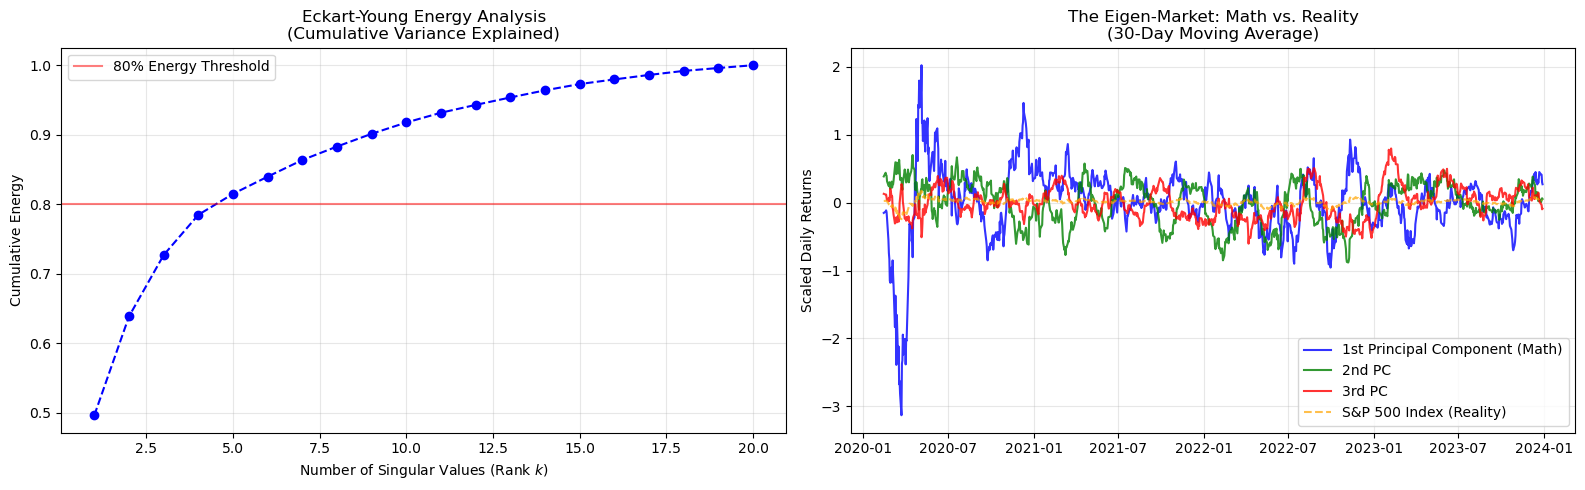

Energy captured by the first singular value alone: 49.61%


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- 1. Load the Frozen Data ---
print("Loading data from local CSV...")
df = pd.read_csv("study1_market_data.csv", index_col=0, parse_dates=True)

# Separate the S&P 500 baseline from the 20 stocks
sp500 = df['SP500']
data = df.drop(columns=['SP500'])

# --- 2. Preprocess into a Time x Stock Matrix ---
# Calculate daily percentage returns and drop the first NaN row
returns = data.pct_change().dropna()
sp500_returns = sp500.pct_change().dropna()

# Standardize the data (mean = 0, variance = 1) so no single stock dominates the SVD
scaler = StandardScaler()
X = scaler.fit_transform(returns)

# --- 3. Compute the SVD ---
# X = U * Sigma * V^T
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# --- 4. Energy & Error Analysis (Eckart-Young Theorem) ---
# Calculate the variance explained by each singular value
eigen_energies = (S ** 2) / np.sum(S ** 2)
cumulative_energy = np.cumsum(eigen_energies)

# --- 5. Extract the "Market Factor" (First Principal Component) ---
# Project the original data onto the first right singular vector
# We flip the sign if necessary to align with the actual market direction
PC1 = X @ Vt[0, :]
PC2 = X @ Vt[1, :]
PC3 = X @ Vt[2, :]

if np.corrcoef(PC1, sp500_returns)[0, 1] < 0: PC1 = -PC1 
if np.corrcoef(PC2, sp500_returns)[0, 1] < 0: PC2 = -PC2 
if np.corrcoef(PC3, sp500_returns)[0, 1] < 0: PC3 = -PC3 


# --- 6. Plot the Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot A: The Eckart-Young Energy Curve
ax1.plot(range(1, len(S) + 1), cumulative_energy, marker='o', linestyle='--', color='b')
ax1.axhline(y=0.80, color='r', linestyle='-', alpha=0.5, label='80% Energy Threshold')
ax1.set_title("Eckart-Young Energy Analysis\n(Cumulative Variance Explained)")
ax1.set_xlabel("Number of Singular Values (Rank $k$)")
ax1.set_ylabel("Cumulative Energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot B: First Principal Component vs S&P 500
# We take a 30-day rolling average to make the visual cleaner
rolling_window = 30
ax2.plot(returns.index, pd.Series(PC1).rolling(rolling_window).mean(), 
         label='1st Principal Component (Math)', color='blue', alpha=0.8)

ax2.plot(returns.index, pd.Series(PC2).rolling(rolling_window).mean(), 
         label='2nd PC', color='green', alpha=0.8)

ax2.plot(returns.index, pd.Series(PC3).rolling(rolling_window).mean(), 
         label='3rd PC', color='red', alpha=0.8)

ax2.plot(sp500_returns.index, sp500_returns.rolling(rolling_window).mean() * 20, 
         label='S&P 500 Index (Reality)', color='orange', alpha=0.7, linestyle='--')
ax2.set_title("The Eigen-Market: Math vs. Reality\n(30-Day Moving Average)")
ax2.set_ylabel("Scaled Daily Returns")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Energy captured by the first singular value alone: {eigen_energies[0]*100:.2f}%")

Loading data from local CSV...
Correlation PC1 vs S&P500: 0.907
Correlation PC2 vs S&P500: 0.337
Correlation PC3 vs S&P500: 0.071


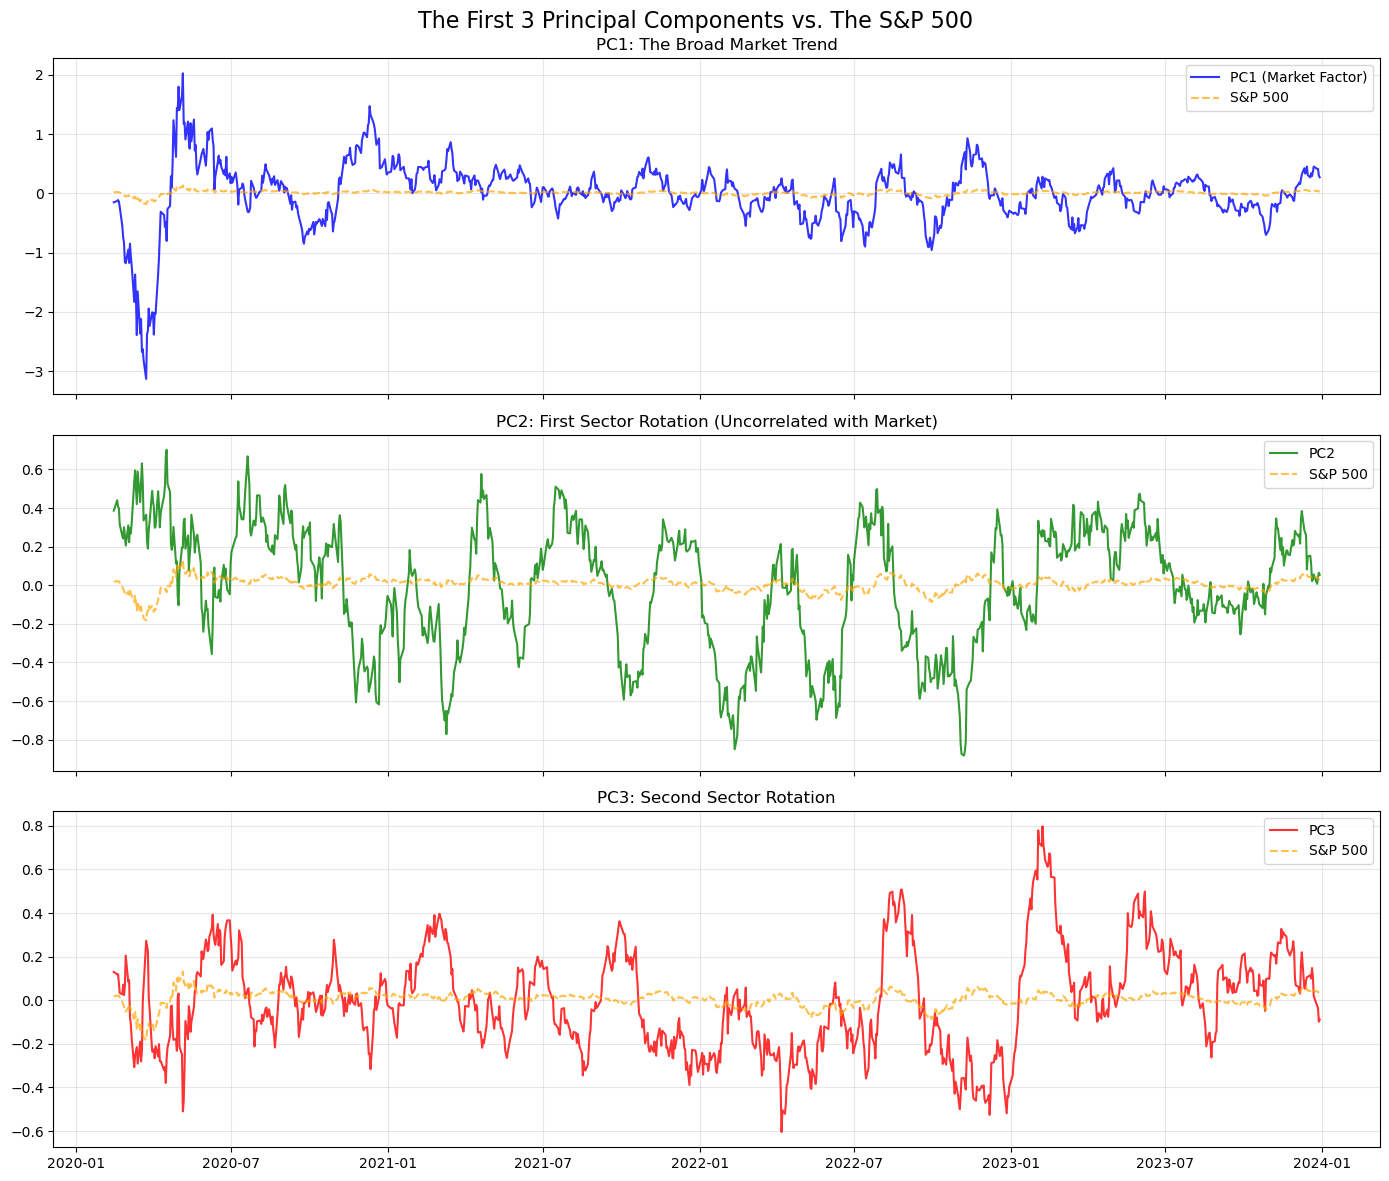

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- 1. Load the Frozen Data ---
print("Loading data from local CSV...")
df = pd.read_csv("study1_market_data.csv", index_col=0, parse_dates=True)

sp500 = df['SP500']
data = df.drop(columns=['SP500'])

# Calculate daily returns
returns = data.pct_change().dropna()
sp500_returns = sp500.pct_change().dropna()

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(returns)

# --- 2. Compute the SVD ---
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# --- 3. Extract the first 3 Principal Components ---
PC1 = X @ Vt[0, :]
PC2 = X @ Vt[1, :]
PC3 = X @ Vt[2, :]

# Align the signs for visualization
if np.corrcoef(PC1, sp500_returns)[0, 1] < 0: PC1 = -PC1 
if np.corrcoef(PC2, sp500_returns)[0, 1] < 0: PC2 = -PC2 
if np.corrcoef(PC3, sp500_returns)[0, 1] < 0: PC3 = -PC3 

# Print exact correlations
print(f"Correlation PC1 vs S&P500: {np.corrcoef(PC1, sp500_returns)[0, 1]:.3f}")
print(f"Correlation PC2 vs S&P500: {np.corrcoef(PC2, sp500_returns)[0, 1]:.3f}")
print(f"Correlation PC3 vs S&P500: {np.corrcoef(PC3, sp500_returns)[0, 1]:.3f}")

# --- 4. Plot the 3 PCs against the S&P 500 ---
rolling_window = 30
sp500_smooth = sp500_returns.rolling(rolling_window).mean() * 15 # scale up to match variance visually

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle("The First 3 Principal Components vs. The S&P 500", fontsize=16)

# PC1 Plot
axes[0].plot(returns.index, pd.Series(PC1).rolling(rolling_window).mean(), label='PC1 (Market Factor)', color='blue', alpha=0.8)
axes[0].plot(sp500_returns.index, sp500_smooth, label='S&P 500', color='orange', alpha=0.7, linestyle='--')
axes[0].set_title("PC1: The Broad Market Trend")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PC2 Plot
axes[1].plot(returns.index, pd.Series(PC2).rolling(rolling_window).mean(), label='PC2', color='green', alpha=0.8)
axes[1].plot(sp500_returns.index, sp500_smooth, label='S&P 500', color='orange', alpha=0.7, linestyle='--')
axes[1].set_title("PC2: First Sector Rotation (Uncorrelated with Market)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# PC3 Plot
axes[2].plot(returns.index, pd.Series(PC3).rolling(rolling_window).mean(), label='PC3', color='red', alpha=0.8)
axes[2].plot(sp500_returns.index, sp500_smooth, label='S&P 500', color='orange', alpha=0.7, linestyle='--')
axes[2].set_title("PC3: Second Sector Rotation")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

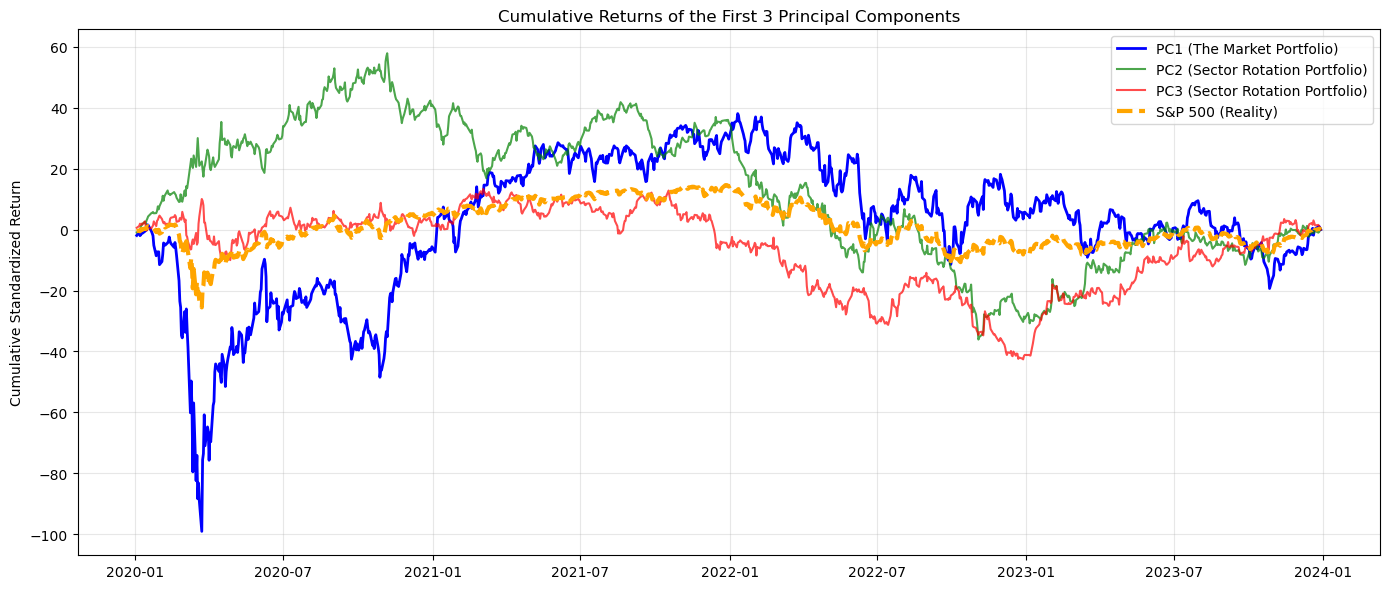

In [12]:
# --- Plotting the Cumulative Returns ("Eigen-Prices") ---
fig, ax = plt.subplots(figsize=(14, 6))

# Standardize the S&P 500 returns so it's on the exact same scale as our PCs
sp500_standardized = scaler.fit_transform(sp500_returns.values.reshape(-1, 1)).flatten()

# We take the cumulative sum to convert daily changes into a continuous trend line
ax.plot(returns.index, np.cumsum(PC1), label='PC1 (The Market Portfolio)', color='blue', linewidth=2)
ax.plot(returns.index, np.cumsum(PC2), label='PC2 (Sector Rotation Portfolio)', color='green', alpha=0.7)
ax.plot(returns.index, np.cumsum(PC3), label='PC3 (Sector Rotation Portfolio)', color='red', alpha=0.7)

# Overlay the S&P 500
ax.plot(sp500_returns.index, np.cumsum(sp500_standardized), 
        label='S&P 500 (Reality)', color='orange', linestyle='--', linewidth=3)

ax.set_title("Cumulative Returns of the First 3 Principal Components")
ax.set_ylabel("Cumulative Standardized Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()